# Supply Chain Logistics Performance Analysis

> An end-to-end Python case study covering data validation, cleaning, feature engineering, exploratory analysis, relationship analysis, and baseline risk classification.

## Executive summary

This project analyses **32,065 hourly logistics observations** recorded between **1 January 2021 and 29 August 2024**. The dataset contains 26 operational, warehouse, transportation, environmental, cost, and risk-related variables.

The analysis produced four central findings:

1. The dataset is technically clean: no missing values, duplicate rows, or invalid timestamps were found.
2. Delivery-time deviation averages **5.18 hours**, with a median of **6.11 hours** and a 90th percentile of **9.92 hours**.
3. **74.67%** of observations are classified as high risk, but delivery-time deviation is almost identical across the three risk classes.
4. A baseline random-forest model predicts only the majority class. Its apparent 76% accuracy is therefore misleading and does not support operational deployment.

The main analytical conclusion is that the available explanatory variables contain little observable signal for delivery-time deviation or for the supplied risk classification. This is a useful portfolio result: clean data and high model accuracy do not automatically imply a meaningful or deployable model.

## Business problem

Logistics teams need to identify conditions associated with delivery disruption so they can prioritise monitoring, investigate bottlenecks, and intervene before service performance deteriorates.

> **Main question:** Which operational, environmental, warehouse, and transportation factors are associated with delivery-time deviation and logistics risk?

## Questions investigated

1. Is the dataset complete, consistent, and suitable for analysis?
2. How does delivery-time deviation behave over time?
3. How are observations distributed across logistics-risk classes?
4. Do risk classes correspond to materially different delivery outcomes?
5. Which operational variables are associated with delivery-time deviation?
6. Can the supplied risk classification be predicted without obvious target leakage?

## Dataset

- **Source:** [Dynamic Supply Chain Logistics Dataset on Kaggle](https://www.kaggle.com/datasets/datasetengineer/logistics-and-supply-chain-dataset/versions/1)
- **File:** `dynamic_supply_chain_logistics_dataset.csv`
- **Licence:** CC0 — Public Domain
- **Rows:** 32,065
- **Source columns:** 26
- **Time coverage:** 2021-01-01 to 2024-08-29
- **Granularity:** Hourly observations

## Tools

- Python
- pandas and NumPy
- Matplotlib
- scikit-learn
- Jupyter Notebook

> **Interpretation note:** Several fields named as statuses are stored as continuous scores. They are retained as numeric scores because the dataset does not provide defensible business thresholds for converting them into binary categories.


## Notebook structure

1. [Environment setup](#1-environment-setup)
2. [Data loading](#2-data-loading)
3. [Initial data assessment](#3-initial-data-assessment)
4. [Data-quality audit](#4-data-quality-audit)
5. [Data cleaning](#5-data-cleaning)
6. [Feature engineering](#6-feature-engineering)
7. [Exploratory data analysis](#7-exploratory-data-analysis)
8. [Relationship analysis](#8-relationship-analysis)
9. [Baseline risk-classification model](#9-baseline-risk-classification-model)
10. [Conclusions and recommendations](#10-conclusions-and-recommendations)


# 1. Environment setup

This section imports the libraries used throughout the analysis and defines consistent display and chart settings.

The modelling components are imported at the start so that the notebook can be executed from top to bottom without additional setup cells.


In [1]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

print("Environment ready.")

Environment ready.


## Project folders

The code in this notebook expects the following local structure:

```text
supply-chain-logistics-analysis/
├── Supply_Chain_Logistics_Analysis.ipynb
├── requirements.txt
├── data/
│   ├── dynamic_supply_chain_logistics_dataset.csv
│   └── processed/
└── reports/
    └── figures/
```

Place the downloaded CSV directly inside `data/`. The notebook creates the processed-data and figure folders automatically.


In [2]:
PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "dynamic_supply_chain_logistics_dataset.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# 2. Data loading

The source CSV is loaded into a pandas DataFrame. The row count, column count, and first five observations are displayed to confirm that the expected file has been read successfully.


In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}\n"
        "Create data/raw/, place the CSV there, or update DATA_PATH."
    )

raw_df = pd.read_csv(DATA_PATH)

print(f"Rows: {raw_df.shape[0]:,}")
print(f"Columns: {raw_df.shape[1]}")
raw_df.head()

Rows: 32,065
Columns: 26


,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,port_congestion_level,shipping_costs,supplier_reliability_score,lead_time_days,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.38,-77.01,5.14,5.00,5.93,985.72,4.95,0.48,0.76,0.36,4.29,456.50,0.99,2.13,100.77,0.57,0.78,1.18,0.50,0.03,0.98,0.51,0.89,Moderate Risk,9.11
1,2021-01-01 01:00:00,33.51,-117.04,5.10,0.98,1.59,396.70,1.03,0.62,0.20,0.23,7.02,640.41,0.46,12.61,"5,313.74",-9.75,0.09,9.61,0.97,0.20,0.92,0.98,0.54,High Risk,8.18
2,2021-01-01 02:00:00,30.02,-75.27,5.09,4.97,8.79,832.41,4.22,0.81,0.15,0.03,9.61,155.75,0.60,14.12,"1,595.05",-6.49,0.25,6.57,0.95,0.26,0.39,1.00,0.80,High Risk,1.28
3,2021-01-01 03:00:00,36.65,-70.19,8.22,3.10,0.05,0.57,0.53,0.01,0.81,0.62,8.90,104.32,0.74,3.82,"2,530.43",-0.15,0.88,0.55,4.67,0.36,0.91,0.99,0.03,High Risk,9.30
4,2021-01-01 04:00:00,30.00,-70.01,5.00,3.22,8.00,914.93,3.62,0.02,0.05,0.95,0.06,977.22,0.43,14.00,"2,146.19",2.43,0.26,8.86,3.45,0.02,0.26,0.91,0.99,High Risk,7.75


# 3. Initial data assessment

Before changing any values, the dataset is reviewed in its original form. This establishes a reproducible baseline and prevents cleaning decisions from being made without evidence.

## Variable groups

| Group | Examples |
|---|---|
| Time and location | Timestamp, GPS latitude, GPS longitude |
| Transportation operations | Fuel consumption, ETA variation, traffic congestion |
| Warehouse operations | Inventory level, loading time, equipment availability |
| External conditions | Weather severity, port congestion, customs-clearance time |
| Supplier and cost | Supplier reliability, lead time, historical demand, shipping cost |
| Monitoring and risk | IoT temperature, cargo condition, route risk, driver behaviour, fatigue |
| Supplied outcomes | Disruption likelihood, delay probability, risk classification, delivery-time deviation |

The assessment covers dimensions, data types, descriptive statistics, missing values, duplicates, category consistency, and numeric ranges.


In [4]:
print("Dataset shape:", raw_df.shape)
raw_df.columns.tolist()

Dataset shape: (32065, 26)


['timestamp',
 'vehicle_gps_latitude',
 'vehicle_gps_longitude',
 'fuel_consumption_rate',
 'eta_variation_hours',
 'traffic_congestion_level',
 'warehouse_inventory_level',
 'loading_unloading_time',
 'handling_equipment_availability',
 'order_fulfillment_status',
 'weather_condition_severity',
 'port_congestion_level',
 'shipping_costs',
 'supplier_reliability_score',
 'lead_time_days',
 'historical_demand',
 'iot_temperature',
 'cargo_condition_status',
 'route_risk_level',
 'customs_clearance_time',
 'driver_behavior_score',
 'fatigue_monitoring_score',
 'disruption_likelihood_score',
 'delay_probability',
 'risk_classification',
 'delivery_time_deviation']

In [5]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32065 entries, 0 to 32064
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   timestamp                        32065 non-null  str    
 1   vehicle_gps_latitude             32065 non-null  float64
 2   vehicle_gps_longitude            32065 non-null  float64
 3   fuel_consumption_rate            32065 non-null  float64
 4   eta_variation_hours              32065 non-null  float64
 5   traffic_congestion_level         32065 non-null  float64
 6   warehouse_inventory_level        32065 non-null  float64
 7   loading_unloading_time           32065 non-null  float64
 8   handling_equipment_availability  32065 non-null  float64
 9   order_fulfillment_status         32065 non-null  float64
 10  weather_condition_severity       32065 non-null  float64
 11  port_congestion_level            32065 non-null  float64
 12  shipping_costs               

In [6]:
raw_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,32065,32065,2021-01-01 00:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_gps_latitude,"32,065.00",NaN,NaN,NaN,38.02,6.92,30.00,31.28,36.41,44.45,50.00
vehicle_gps_longitude,"32,065.00",NaN,NaN,NaN,-90.12,17.37,-120.00,-106.25,-86.29,-73.08,-70.00
fuel_consumption_rate,"32,065.00",NaN,NaN,NaN,8.01,4.26,5.00,5.02,5.64,9.67,20.00
eta_variation_hours,"32,065.00",NaN,NaN,NaN,2.89,2.27,-2.00,1.19,3.88,4.88,5.00
traffic_congestion_level,"32,065.00",NaN,NaN,NaN,4.99,3.53,0.00,1.47,4.98,8.53,10.00
warehouse_inventory_level,"32,065.00",NaN,NaN,NaN,299.25,323.44,0.00,16.05,157.29,540.60,"1,000.00"
loading_unloading_time,"32,065.00",NaN,NaN,NaN,2.29,1.55,0.50,0.77,1.92,3.73,5.00
handling_equipment_availability,"32,065.00",NaN,NaN,NaN,0.30,0.33,0.00,0.02,0.16,0.55,1.00
order_fulfillment_status,"32,065.00",NaN,NaN,NaN,0.60,0.35,0.00,0.28,0.68,0.94,1.00


## 3.1 Standardise column names

Column names are converted to lowercase `snake_case`. This makes references consistent, reduces typing errors, and improves compatibility with reusable Python functions.

No business values are changed in this step.


In [7]:
def normalise_column_name(name: str) -> str:
    cleaned = re.sub(r"[^a-zA-Z0-9]+", "_", name.strip().lower())
    return cleaned.strip("_")

df = raw_df.copy()
df.columns = [normalise_column_name(column) for column in df.columns]
df.columns.tolist()

['timestamp',
 'vehicle_gps_latitude',
 'vehicle_gps_longitude',
 'fuel_consumption_rate',
 'eta_variation_hours',
 'traffic_congestion_level',
 'warehouse_inventory_level',
 'loading_unloading_time',
 'handling_equipment_availability',
 'order_fulfillment_status',
 'weather_condition_severity',
 'port_congestion_level',
 'shipping_costs',
 'supplier_reliability_score',
 'lead_time_days',
 'historical_demand',
 'iot_temperature',
 'cargo_condition_status',
 'route_risk_level',
 'customs_clearance_time',
 'driver_behavior_score',
 'fatigue_monitoring_score',
 'disruption_likelihood_score',
 'delay_probability',
 'risk_classification',
 'delivery_time_deviation']

## 3.2 Validate the expected schema

A fixed set of expected columns is compared with the loaded file.

This check prevents the notebook from silently analysing an incomplete file, a renamed export, or a different dataset version. Execution stops if a required column is missing.


In [8]:
EXPECTED_COLUMNS = {
    "timestamp", "vehicle_gps_latitude", "vehicle_gps_longitude",
    "fuel_consumption_rate", "eta_variation_hours",
    "traffic_congestion_level", "warehouse_inventory_level",
    "loading_unloading_time", "handling_equipment_availability",
    "order_fulfillment_status", "weather_condition_severity",
    "port_congestion_level", "shipping_costs",
    "supplier_reliability_score", "lead_time_days",
    "historical_demand", "iot_temperature",
    "cargo_condition_status", "route_risk_level",
    "customs_clearance_time", "driver_behavior_score",
    "fatigue_monitoring_score", "disruption_likelihood_score",
    "delay_probability", "risk_classification",
    "delivery_time_deviation",
}

missing_columns = sorted(EXPECTED_COLUMNS - set(df.columns))
unexpected_columns = sorted(set(df.columns) - EXPECTED_COLUMNS)

print("Missing columns:", missing_columns)
print("Unexpected columns:", unexpected_columns)

if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")

Missing columns: []
Unexpected columns: []


# 4. Data-quality audit

The audit evaluates:

- missing values;
- exact duplicate rows;
- data types;
- unique-value counts;
- category distributions;
- numeric minimums and maximums.

### Audit result

The source contains **32,065 rows and 26 columns**, with:

- no missing values;
- no exact duplicate rows;
- 24 numeric fields;
- two text fields before conversion: `timestamp` and `risk_classification`.

A technically complete dataset can still contain unclear definitions or unrealistic relationships, so semantic quality is assessed separately from missingness and duplication.


In [9]:
def build_quality_report(dataframe: pd.DataFrame) -> pd.DataFrame:
    return (
        pd.DataFrame({
            "column": dataframe.columns,
            "dtype": dataframe.dtypes.astype(str).values,
            "missing_count": dataframe.isna().sum().values,
            "missing_percent": dataframe.isna().mean().mul(100).round(2).values,
            "unique_values": dataframe.nunique(dropna=False).values,
        })
        .sort_values(["missing_percent", "unique_values"], ascending=[False, True])
        .reset_index(drop=True)
    )

raw_quality_report = build_quality_report(df)
raw_quality_report

,column,dtype,missing_count,missing_percent,unique_values
0,risk_classification,str,0,0.00,3
1,disruption_likelihood_score,float64,0,0.00,32030
2,iot_temperature,float64,0,0.00,32031
3,fuel_consumption_rate,float64,0,0.00,32037
4,timestamp,str,0,0.00,32065
5,vehicle_gps_latitude,float64,0,0.00,32065
6,vehicle_gps_longitude,float64,0,0.00,32065
7,eta_variation_hours,float64,0,0.00,32065
8,traffic_congestion_level,float64,0,0.00,32065
9,warehouse_inventory_level,float64,0,0.00,32065


In [10]:
print(f"Exact duplicate rows: {df.duplicated().sum():,}")

Exact duplicate rows: 0


## 4.1 Inspect important category and status fields

The supplied risk label has three categories, while several variables described as levels or statuses contain highly granular continuous values.

For example:

- `traffic_congestion_level` and `route_risk_level` range from 0 to 10;
- `weather_condition_severity` and several status scores range from 0 to 1;
- `risk_classification` contains Low, Moderate, and High Risk.

These continuous variables are not converted into arbitrary categories during cleaning. Binning is used only later where it supports a specific analytical comparison.


In [11]:
columns_to_review = [
    "risk_classification", "traffic_congestion_level",
    "weather_condition_severity", "port_congestion_level",
    "route_risk_level", "order_fulfillment_status",
    "cargo_condition_status",
]

for column in columns_to_review:
    print(f"\n{column}")
    print("-" * len(column))
    print(df[column].value_counts(dropna=False).head(15))


risk_classification
-------------------
risk_classification
High Risk        23944
Moderate Risk     5011
Low Risk          3110
Name: count, dtype: int64

traffic_congestion_level
------------------------
traffic_congestion_level
5.93    1
1.59    1
8.79    1
0.05    1
8.00    1
0.50    1
8.75    1
4.81    1
9.61    1
9.90    1
8.45    1
0.25    1
1.11    1
6.23    1
9.20    1
Name: count, dtype: int64

weather_condition_severity
--------------------------
weather_condition_severity
0.36    1
0.23    1
0.03    1
0.62    1
0.95    1
0.70    1
0.36    1
0.61    1
0.87    1
0.80    1
0.01    1
0.76    1
0.29    1
0.00    1
0.69    1
Name: count, dtype: int64

port_congestion_level
---------------------
port_congestion_level
4.29    1
7.02    1
9.61    1
8.90    1
0.06    1
9.96    1
7.51    1
9.59    1
8.45    1
9.84    1
4.01    1
1.97    1
5.47    1
9.62    1
3.78    1
Name: count, dtype: int64

route_risk_level
----------------
route_risk_level
1.18     1
9.61     1
6.57     1
0.55  

## 4.2 Inspect numeric ranges

Numeric ranges are reviewed before deciding whether any observation should be removed.

Notable values include:

- ETA variation and delivery-time deviation can be negative, which may represent earlier-than-expected performance rather than an error;
- IoT temperature ranges from -10 to 40;
- shipping cost ranges from 100 to 1,000 in unspecified dataset units;
- several scores are bounded between 0 and 1;
- congestion and route-risk measures are bounded between 0 and 10.

Because no authoritative operational limits or data dictionary rules are available, no observation is removed solely because it is extreme. This avoids replacing evidence-based cleaning with subjective assumptions.


In [12]:
numeric_range_report = (
    df.select_dtypes(include=np.number)
      .agg(["count", "mean", "std", "min", "median", "max"])
      .T
)
numeric_range_report

,count,mean,std,min,median,max
vehicle_gps_latitude,"32,065.00",38.02,6.92,30.00,36.41,50.00
vehicle_gps_longitude,"32,065.00",-90.12,17.37,-120.00,-86.29,-70.00
fuel_consumption_rate,"32,065.00",8.01,4.26,5.00,5.64,20.00
eta_variation_hours,"32,065.00",2.89,2.27,-2.00,3.88,5.00
traffic_congestion_level,"32,065.00",4.99,3.53,0.00,4.98,10.00
warehouse_inventory_level,"32,065.00",299.25,323.44,0.00,157.29,"1,000.00"
loading_unloading_time,"32,065.00",2.29,1.55,0.50,1.92,5.00
handling_equipment_availability,"32,065.00",0.30,0.33,0.00,0.16,1.00
order_fulfillment_status,"32,065.00",0.60,0.35,0.00,0.68,1.00
weather_condition_severity,"32,065.00",0.50,0.35,0.00,0.50,1.00


# 5. Data cleaning

The cleaning workflow is deliberately conservative:

1. Convert `timestamp` to datetime.
2. Coerce expected numeric columns to numeric data types.
3. Standardise spacing and capitalisation in `risk_classification`.
4. Remove exact duplicate rows.
5. Sort observations chronologically.
6. Convert risk classification into an ordered category.

### Cleaning outcome

- Rows before cleaning: **32,065**
- Rows after cleaning: **32,065**
- Duplicate rows removed: **0**
- Invalid timestamps: **0**

No source records are discarded.


In [13]:
clean_df = df.copy()

clean_df["timestamp"] = pd.to_datetime(clean_df["timestamp"], errors="coerce")

numeric_columns = clean_df.columns.difference(["timestamp", "risk_classification"])
clean_df[numeric_columns] = clean_df[numeric_columns].apply(
    pd.to_numeric, errors="coerce"
)

clean_df["risk_classification"] = (
    clean_df["risk_classification"]
    .astype("string")
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.title()
)

rows_before = len(clean_df)
clean_df = (
    clean_df.drop_duplicates()
    .sort_values("timestamp")
    .reset_index(drop=True)
)

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning: {len(clean_df):,}")
print(f"Duplicates removed: {rows_before - len(clean_df):,}")
print(f"Invalid timestamps: {clean_df['timestamp'].isna().sum():,}")

Rows before cleaning: 32,065
Rows after cleaning: 32,065
Duplicates removed: 0
Invalid timestamps: 0


In [14]:
risk_order = ["Low Risk", "Moderate Risk", "High Risk"]

print(clean_df["risk_classification"].value_counts(dropna=False))

clean_df["risk_classification"] = pd.Categorical(
    clean_df["risk_classification"],
    categories=risk_order,
    ordered=True,
)

risk_classification
High Risk        23944
Moderate Risk     5011
Low Risk          3110
Name: count, dtype: Int64


## 5.1 Quality report after cleaning

The post-cleaning report confirms that:

- the timestamp is stored as a datetime;
- risk classification is an ordered categorical variable;
- all expected numeric variables remain numeric;
- no missing values were introduced;
- all 32,065 records were retained.

This report is exported later so that the project includes an auditable record of the final analysis dataset.


In [15]:
clean_quality_report = build_quality_report(clean_df)
clean_quality_report

,column,dtype,missing_count,missing_percent,unique_values
0,risk_classification,category,0,0.00,3
1,disruption_likelihood_score,float64,0,0.00,32030
2,iot_temperature,float64,0,0.00,32031
3,fuel_consumption_rate,float64,0,0.00,32037
4,timestamp,datetime64[us],0,0.00,32065
5,vehicle_gps_latitude,float64,0,0.00,32065
6,vehicle_gps_longitude,float64,0,0.00,32065
7,eta_variation_hours,float64,0,0.00,32065
8,traffic_congestion_level,float64,0,0.00,32065
9,warehouse_inventory_level,float64,0,0.00,32065


# 6. Feature engineering

The following analysis features are created from the cleaned data:

| Feature | Definition | Purpose |
|---|---|---|
| `year` | Calendar year | Long-term comparison |
| `month` | Year-month period | Monthly trend analysis |
| `month_number` | Month from 1 to 12 | Seasonal analysis |
| `day_of_week` | Weekday name | Weekly operational patterns |
| `hour` | Hour of day | Intraday analysis |
| `is_weekend` | Saturday or Sunday | Weekday/weekend comparison |
| `high_delay_flag` | Delivery deviation at or above the 75th percentile | Relative high-delay segmentation |
| `supplier_reliability_band` | Low, Medium, or High reliability | Group comparison |
| `shipping_cost_band` | Cost quartiles | Non-linear cost comparison |

The high-delay threshold is **9.25 hours**. It is a dataset-relative analytical threshold, not an agreed service-level target or contractual definition of lateness.


In [16]:
clean_df["year"] = clean_df["timestamp"].dt.year
clean_df["month"] = clean_df["timestamp"].dt.to_period("M").astype("string")
clean_df["month_number"] = clean_df["timestamp"].dt.month
clean_df["day_of_week"] = clean_df["timestamp"].dt.day_name()
clean_df["hour"] = clean_df["timestamp"].dt.hour
clean_df["is_weekend"] = clean_df["timestamp"].dt.dayofweek.ge(5)

delay_threshold = clean_df["delivery_time_deviation"].quantile(0.75)
clean_df["high_delay_flag"] = (
    clean_df["delivery_time_deviation"] >= delay_threshold
).astype("int8")

clean_df["supplier_reliability_band"] = pd.cut(
    clean_df["supplier_reliability_score"],
    bins=[-np.inf, 0.4, 0.7, np.inf],
    labels=["Low", "Medium", "High"],
)

clean_df["shipping_cost_band"] = pd.qcut(
    clean_df["shipping_costs"],
    q=4,
    labels=["Q1: Lowest", "Q2", "Q3", "Q4: Highest"],
    duplicates="drop",
)

print(f"High-delay threshold: {delay_threshold:,.2f} hours")
clean_df.head()

High-delay threshold: 9.25 hours


,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,port_congestion_level,shipping_costs,supplier_reliability_score,lead_time_days,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation,year,month,month_number,day_of_week,hour,is_weekend,high_delay_flag,supplier_reliability_band,shipping_cost_band
0,2021-01-01 00:00:00,40.38,-77.01,5.14,5.00,5.93,985.72,4.95,0.48,0.76,0.36,4.29,456.50,0.99,2.13,100.77,0.57,0.78,1.18,0.50,0.03,0.98,0.51,0.89,Moderate Risk,9.11,2021,2021-01,1,Friday,0,False,0,High,Q3
1,2021-01-01 01:00:00,33.51,-117.04,5.10,0.98,1.59,396.70,1.03,0.62,0.20,0.23,7.02,640.41,0.46,12.61,"5,313.74",-9.75,0.09,9.61,0.97,0.20,0.92,0.98,0.54,High Risk,8.18,2021,2021-01,1,Friday,1,False,0,Medium,Q3
2,2021-01-01 02:00:00,30.02,-75.27,5.09,4.97,8.79,832.41,4.22,0.81,0.15,0.03,9.61,155.75,0.60,14.12,"1,595.05",-6.49,0.25,6.57,0.95,0.26,0.39,1.00,0.80,High Risk,1.28,2021,2021-01,1,Friday,2,False,0,Medium,Q2
3,2021-01-01 03:00:00,36.65,-70.19,8.22,3.10,0.05,0.57,0.53,0.01,0.81,0.62,8.90,104.32,0.74,3.82,"2,530.43",-0.15,0.88,0.55,4.67,0.36,0.91,0.99,0.03,High Risk,9.30,2021,2021-01,1,Friday,3,False,1,High,Q1: Lowest
4,2021-01-01 04:00:00,30.00,-70.01,5.00,3.22,8.00,914.93,3.62,0.02,0.05,0.95,0.06,977.22,0.43,14.00,"2,146.19",2.43,0.26,8.86,3.45,0.02,0.26,0.91,0.99,High Risk,7.75,2021,2021-01,1,Friday,4,False,0,Medium,Q4: Highest


## 6.1 Export the cleaned data

The analysis-ready dataset and its data-quality report are saved under `data/processed/`.

These files can be reused in a dashboard or a separate modelling notebook without repeating the cleaning workflow.


In [ ]:
processed_path = PROCESSED_DIR / "supply_chain_clean.csv"
quality_path = PROCESSED_DIR / "data_quality_report.csv"

clean_df.to_csv(processed_path, index=False)
clean_quality_report.to_csv(quality_path, index=False)

# 7. Exploratory data analysis

The exploratory analysis summarises overall performance, temporal patterns, class balance, and group-level differences.

Each result is interpreted using three questions:

1. What does the result show?
2. Is the difference operationally meaningful?
3. What decision or further investigation could it support?


## 7.1 KPI overview

The KPI table provides a concise view of the dataset period, delivery deviation, ETA variation, cost, lead time, and risk composition.


In [18]:
risk_as_text = clean_df["risk_classification"].astype("string")

kpi_summary = pd.Series({
    "Total records": len(clean_df),
    "Start timestamp": clean_df["timestamp"].min(),
    "End timestamp": clean_df["timestamp"].max(),
    "Average delivery deviation (hours)": clean_df["delivery_time_deviation"].mean(),
    "Median delivery deviation (hours)": clean_df["delivery_time_deviation"].median(),
    "P90 delivery deviation (hours)": clean_df["delivery_time_deviation"].quantile(0.90),
    "Average ETA variation (hours)": clean_df["eta_variation_hours"].mean(),
    "Average shipping cost": clean_df["shipping_costs"].mean(),
    "Average lead time (days)": clean_df["lead_time_days"].mean(),
    "High-risk share (%)": risk_as_text.eq("High Risk").mean() * 100,
    "High-delay share (%)": clean_df["high_delay_flag"].mean() * 100,
}, name="value")

kpi_summary.to_frame()

,value
Total records,32065
Start timestamp,2021-01-01 00:00:00
End timestamp,2024-08-29 00:00:00
Average delivery deviation (hours),5.18
Median delivery deviation (hours),6.11
P90 delivery deviation (hours),9.92
Average ETA variation (hours),2.89
Average shipping cost,459.37
Average lead time (days),5.23
High-risk share (%),74.67


### KPI interpretation

- Average delivery-time deviation is **5.18 hours**, while the median is higher at **6.11 hours**. Lower and negative observations pull the mean below the median.
- The 90th percentile is **9.92 hours**, close to the upper limit of 10 hours in the dataset.
- Average ETA variation is **2.89 hours** and average lead time is **5.23 days**.
- Average shipping cost is **459.37** in the dataset's unspecified cost units.
- The supplied label classifies **74.67%** of observations as high risk.
- The high-delay share is exactly **25% by construction**, because the flag uses the 75th percentile.

The unusually large high-risk share requires caution: accuracy alone will be misleading in any classification model.


## 7.2 Delivery-time deviation over time

Monthly mean and median delivery-time deviation are calculated to assess long-term movement, seasonality, and volatility.


In [19]:
monthly_delay = (
    clean_df.set_index("timestamp")["delivery_time_deviation"]
    .resample("MS")
    .agg(["mean", "median", "count"])
)
monthly_delay.head()

,mean,median,count
timestamp,,,
2021-01-01,5.11,6.06,744
2021-02-01,5.16,6.13,672
2021-03-01,5.32,6.48,744
2021-04-01,5.03,5.89,720
2021-05-01,4.98,5.37,744


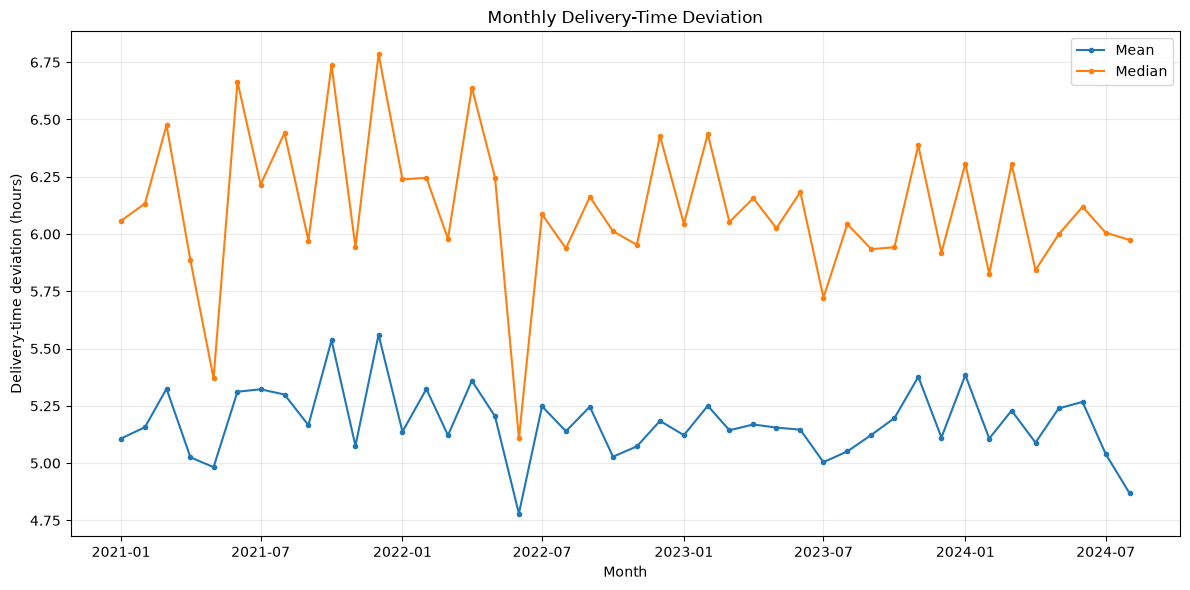

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(monthly_delay.index, monthly_delay["mean"], marker="o", markersize=3, label="Mean")
ax.plot(monthly_delay.index, monthly_delay["median"], marker="o", markersize=3, label="Median")
ax.set_title("Monthly Delivery-Time Deviation")
ax.set_xlabel("Month")
ax.set_ylabel("Delivery-time deviation (hours)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "monthly_delivery_deviation.png", dpi=200, bbox_inches="tight")
plt.show()

### Finding: no clear long-term deterioration or seasonality

Monthly average deviation remains close to five hours throughout the observed period. The monthly median is more volatile, but neither measure shows a sustained upward or downward trend.

This suggests that month alone is unlikely to explain delivery deviation. Operational monitoring should therefore focus on more granular shipment or route-level drivers rather than assuming a broad time trend.


## 7.3 Logistics-risk distribution

The distribution of the supplied target variable is reviewed before comparing groups or fitting a classifier.


In [22]:
risk_counts = (
    clean_df["risk_classification"]
    .value_counts(sort=False)
    .reindex(risk_order)
)
risk_percent = (
    clean_df["risk_classification"]
    .value_counts(normalize=True, sort=False)
    .reindex(risk_order)
    .mul(100)
)
pd.DataFrame({"records": risk_counts, "percent": risk_percent.round(2)})

,records,percent
risk_classification,,
Low Risk,3110,9.70
Moderate Risk,5011,15.63
High Risk,23944,74.67


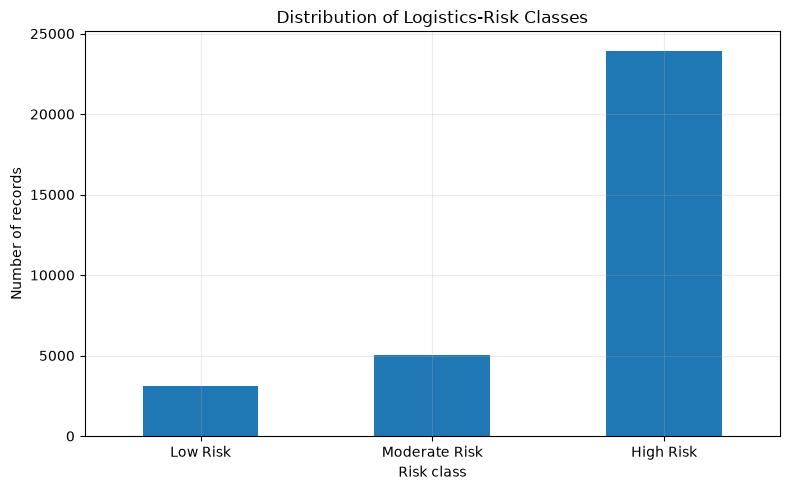

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
risk_counts.plot(kind="bar", ax=ax)
ax.set_title("Distribution of Logistics-Risk Classes")
ax.set_xlabel("Risk class")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "risk_class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

### Finding: the target is strongly imbalanced

| Risk class | Records | Share |
|---|---:|---:|
| Low Risk | 3,110 | 9.70% |
| Moderate Risk | 5,011 | 15.63% |
| High Risk | 23,944 | 74.67% |

A classifier can achieve approximately 75% accuracy by assigning every record to High Risk. Model evaluation must therefore include class-level recall, precision, F1 score, and a confusion matrix rather than accuracy alone.


## 7.4 Delivery deviation by risk class

Delivery-time deviation is compared across Low, Moderate, and High Risk observations to test whether the supplied risk label separates materially different delivery outcomes.


In [24]:
delay_by_risk = (
    clean_df.groupby("risk_classification", observed=False)["delivery_time_deviation"]
    .agg(["count", "mean", "median", "std"])
)
delay_by_risk

,count,mean,median,std
risk_classification,,,,
Low Risk,3110,5.12,5.98,4.14
Moderate Risk,5011,5.18,5.99,4.15
High Risk,23944,5.18,6.14,4.16


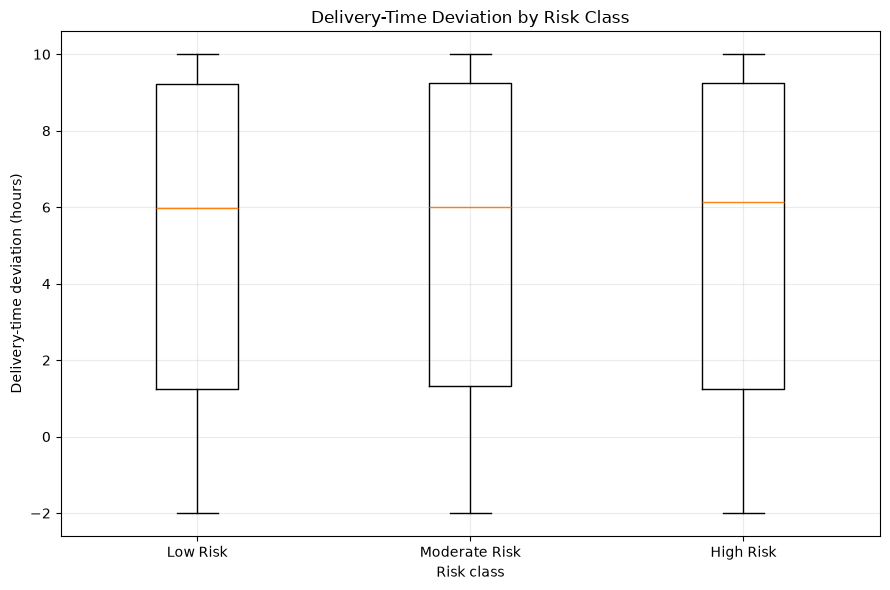

In [25]:
values = [
    clean_df.loc[
        clean_df["risk_classification"].astype("string").eq(risk),
        "delivery_time_deviation",
    ].dropna()
    for risk in risk_order
]

fig, ax = plt.subplots(figsize=(9, 6))
ax.boxplot(values, tick_labels=risk_order, showfliers=False)
ax.set_title("Delivery-Time Deviation by Risk Class")
ax.set_xlabel("Risk class")
ax.set_ylabel("Delivery-time deviation (hours)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "delivery_deviation_by_risk.png", dpi=200, bbox_inches="tight")
plt.show()

### Finding: risk classes do not separate delivery outcomes

Average delivery deviation is:

- **5.12 hours** for Low Risk;
- **5.18 hours** for Moderate Risk;
- **5.18 hours** for High Risk.

Medians and standard deviations are also almost identical. The box plots overlap extensively.

Within this dataset, a High Risk label should therefore not be interpreted as evidence of greater delivery-time deviation. The target may represent another form of disruption risk, may depend on excluded variables, or may have been generated independently of the observed delivery outcome.


## 7.5 Delivery deviation by weekday

Average deviation is compared across the seven days of the week to identify possible recurring scheduling or capacity effects.


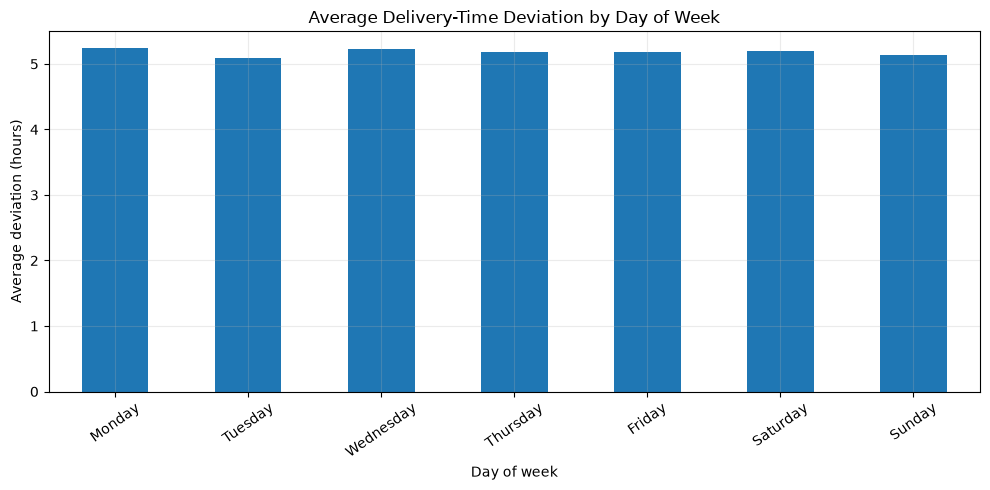

In [26]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday",
]

delay_by_weekday = (
    clean_df.groupby("day_of_week")["delivery_time_deviation"]
    .mean()
    .reindex(weekday_order)
)

fig, ax = plt.subplots(figsize=(10, 5))
delay_by_weekday.plot(kind="bar", ax=ax)
ax.set_title("Average Delivery-Time Deviation by Day of Week")
ax.set_xlabel("Day of week")
ax.set_ylabel("Average deviation (hours)")
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "delay_by_weekday.png", dpi=200, bbox_inches="tight")
plt.show()

### Finding: weekday differences are negligible

Average delivery-time deviation is approximately 5.1 to 5.2 hours on every day of the week. No weekday displays a materially different outcome.

Weekday-based staffing or scheduling recommendations would not be justified from this dataset alone.


# 8. Relationship analysis

This section tests whether individual operational variables move with delivery-time deviation.

Pearson correlation measures linear association only. A value near zero does not rule out non-linear effects, interactions, subgroup behaviour, or causal relationships. Results are used as screening evidence rather than proof of causation.


## 8.1 Correlations with delivery-time deviation

Numeric variables are ranked by the absolute value of their Pearson correlation with delivery-time deviation.


In [27]:
numeric_df = clean_df.select_dtypes(include=np.number)

delay_correlations = (
    numeric_df.corr(numeric_only=True)["delivery_time_deviation"]
    .drop("delivery_time_deviation")
    .dropna()
    .sort_values(key=np.abs, ascending=False)
)

delay_correlations.to_frame("correlation")

,correlation
high_delay_flag,0.64
hour,-0.02
fuel_consumption_rate,0.01
port_congestion_level,0.01
customs_clearance_time,-0.01
warehouse_inventory_level,-0.01
year,-0.01
delay_probability,0.01
handling_equipment_availability,-0.00
supplier_reliability_score,0.00


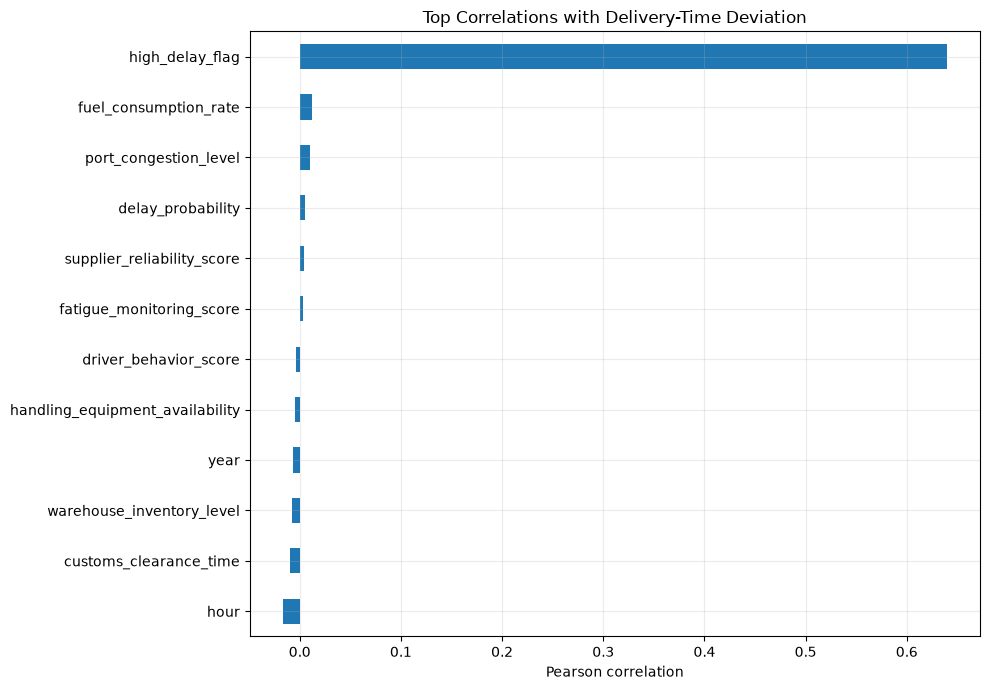

In [28]:
top_correlations = delay_correlations.head(12).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
top_correlations.plot(kind="barh", ax=ax)
ax.set_title("Top Correlations with Delivery-Time Deviation")
ax.set_xlabel("Pearson correlation")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "delivery_deviation_correlations.png", dpi=200, bbox_inches="tight")
plt.show()

### Finding: no original numeric variable has a meaningful linear correlation

`high_delay_flag` has a correlation of approximately **0.64**, but this is expected because it is directly derived from `delivery_time_deviation`. It is not an independent explanatory factor and must not be treated as a business driver.

All original operational variables have correlations close to zero, with absolute values around 0.02 or less. The data therefore provides no evidence of a meaningful linear relationship between delivery deviation and congestion, cost, supplier reliability, weather, route risk, customs time, or the other measured factors.

Possible explanations include:

- relationships may be non-linear or interaction-based;
- important route, carrier, or shipment identifiers may be absent;
- the supplied variables may have been generated independently;
- delivery deviation may require a different target definition.


## 8.2 Supplier reliability

Supplier reliability is divided into Low, Medium, and High bands to test for a possible non-linear relationship with delivery-time deviation.


In [29]:
supplier_summary = (
    clean_df.groupby("supplier_reliability_band", observed=False)["delivery_time_deviation"]
    .agg(["count", "mean", "median", "std"])
)
supplier_summary

,count,mean,median,std
supplier_reliability_band,,,,
Low,13938,5.17,6.10,4.16
Medium,6246,5.16,6.17,4.18
High,11881,5.20,6.09,4.14


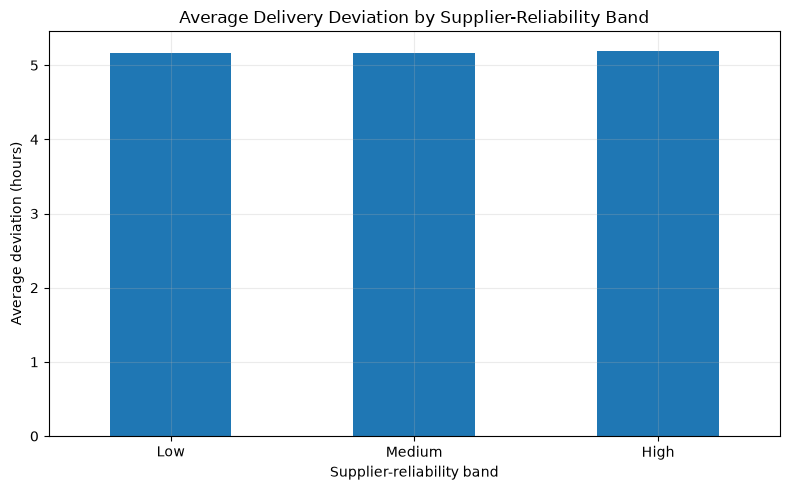

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
supplier_summary["mean"].plot(kind="bar", ax=ax)
ax.set_title("Average Delivery Deviation by Supplier-Reliability Band")
ax.set_xlabel("Supplier-reliability band")
ax.set_ylabel("Average deviation (hours)")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "delay_by_supplier_reliability.png", dpi=200, bbox_inches="tight")
plt.show()

### Finding: supplier-reliability bands have almost identical outcomes

Average delivery deviation is **5.17 hours** for Low reliability, **5.16 hours** for Medium reliability, and **5.20 hours** for High reliability.

The differences are too small and inconsistent to support a claim that higher supplier reliability reduces delivery deviation in this dataset.

## 8.3 Shipping cost versus delivery deviation

The scatter plot and cost-quartile summary test whether higher spending is associated with improved delivery performance.


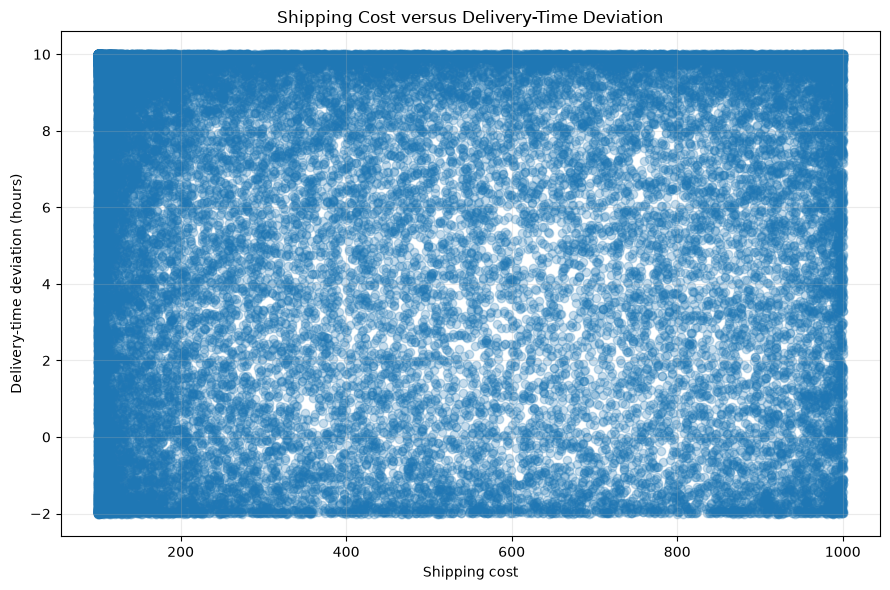

In [31]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    clean_df["shipping_costs"],
    clean_df["delivery_time_deviation"],
    alpha=0.25,
)
ax.set_title("Shipping Cost versus Delivery-Time Deviation")
ax.set_xlabel("Shipping cost")
ax.set_ylabel("Delivery-time deviation (hours)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "shipping_cost_vs_delay.png", dpi=200, bbox_inches="tight")
plt.show()

In [32]:
clean_df.groupby(
    "shipping_cost_band", observed=False
)["delivery_time_deviation"].agg(["count", "mean", "median"])

,count,mean,median
shipping_cost_band,,,
Q1: Lowest,8017,5.21,6.21
Q2,8016,5.16,6.08
Q3,8016,5.14,6.07
Q4: Highest,8016,5.21,6.11


### Finding: shipping cost does not explain delivery deviation

Average delivery deviation by shipping-cost quartile is:

| Cost band | Average deviation |
|---|---:|
| Q1: Lowest | 5.21 hours |
| Q2 | 5.16 hours |
| Q3 | 5.14 hours |
| Q4: Highest | 5.21 hours |

The scatter plot shows no visible pattern, and the quartile averages are effectively equal. Higher shipping cost is not associated with lower delivery deviation in the available data.

## Main analytical findings

### 1. Risk classification is not aligned with delivery-time deviation

- **Evidence:** Mean deviation ranges only from 5.12 to 5.18 hours across risk classes.
- **Business impact:** The supplied label cannot be used as a proxy for late-delivery severity.
- **Recommended investigation:** Confirm how `risk_classification` was generated and what operational event it is intended to represent.

### 2. The measured factors provide little explanatory signal for delivery deviation

- **Evidence:** Original numeric variables have correlations close to zero; weekday and monthly patterns are also weak.
- **Business impact:** Root-cause recommendations based on these fields would be speculative.
- **Recommended investigation:** Add shipment, route, carrier, origin, destination, planned date, and actual date fields.

### 3. Cost and supplier reliability do not distinguish delivery performance

- **Evidence:** Supplier bands and shipping-cost quartiles have nearly identical average deviations.
- **Business impact:** The dataset does not support increasing shipping expenditure or prioritising suppliers as delay-reduction actions.
- **Recommended investigation:** Analyse these factors within comparable routes, service levels, and shipment types rather than across all records.


# 9. Baseline risk-classification model

A random-forest classifier is included as a diagnostic baseline rather than as a deployment-ready solution.

## Leakage controls

The following variables are excluded because they may be direct inputs or close proxies for the supplied target:

- `delay_probability`
- `disruption_likelihood_score`
- `delivery_time_deviation`
- `high_delay_flag`

## Validation approach

- The earliest 80% of records are used for training.
- The latest 20% are used for testing.
- A chronological split is preferred to a random split because the observations are time ordered.
- Numeric values are median-imputed within the pipeline.
- Categorical features are one-hot encoded.
- Class weighting is enabled to address target imbalance.

The model is evaluated using class-level precision, recall, F1 score, and a confusion matrix.


In [33]:
TARGET = "risk_classification"
LEAKAGE_COLUMNS = [
    "delay_probability",
    "disruption_likelihood_score",
    "delivery_time_deviation",
    "high_delay_flag",
]
NON_PREDICTIVE_COLUMNS = ["timestamp", "month", TARGET]

model_df = clean_df.dropna(subset=[TARGET]).copy()

feature_columns = [
    column
    for column in model_df.columns
    if column not in LEAKAGE_COLUMNS + NON_PREDICTIVE_COLUMNS
]

X = model_df[feature_columns]
y = model_df[TARGET].astype("string")

split_index = int(len(model_df) * 0.80)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Features:", len(feature_columns))

Training rows: 25652
Test rows: 6413
Features: 28


In [34]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([("imputer", SimpleImputer(strategy="median"))]),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]),
            categorical_features,
        ),
    ]
)

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
    )),
])

baseline_model.fit(X_train, y_train)
predictions = baseline_model.predict(X_test)

print(classification_report(y_test, predictions))

               precision    recall  f1-score   support

    High Risk       0.76      1.00      0.86      4865
     Low Risk       0.00      0.00      0.00       578
Moderate Risk       0.00      0.00      0.00       970

     accuracy                           0.76      6413
    macro avg       0.25      0.33      0.29      6413
 weighted avg       0.58      0.76      0.65      6413



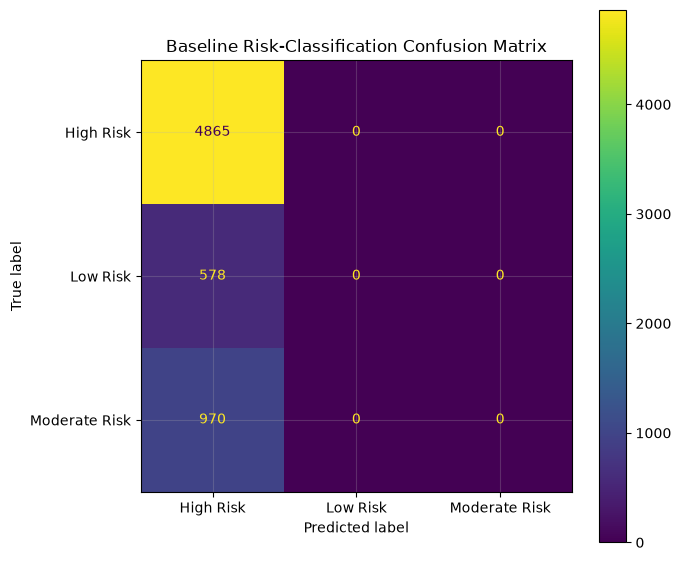

In [35]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_test, predictions, ax=ax)
ax.set_title("Baseline Risk-Classification Confusion Matrix")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "baseline_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

### Model results and interpretation

The model predicts **every test observation as High Risk**.

| Metric | Result |
|---|---:|
| Overall accuracy | 0.76 |
| High Risk recall | 1.00 |
| Low Risk recall | 0.00 |
| Moderate Risk recall | 0.00 |
| Macro-average F1 | 0.29 |

The 76% accuracy is approximately the same as a majority-class rule because High Risk represents most test observations. The model does not identify either minority class and therefore provides no practical classification capability.

### Decision

This model should **not** be used operationally.

### What the failed baseline reveals

- Class imbalance is severe.
- The retained predictors do not contain enough separable signal for the supplied target.
- Class weighting alone cannot solve a weak target-feature relationship.
- Further model tuning would be premature until the target definition and data-generation process are understood.

A stronger next step is to establish a transparent majority-class baseline, investigate target construction, and test whether any leakage-safe variables genuinely differ by class.


# 10. Conclusions and recommendations

## Conclusion

The dataset is structurally clean and the notebook creates a reproducible analysis pipeline. However, the analytical relationships required for reliable operational recommendations are largely absent.

The supplied risk classification is heavily imbalanced and does not correspond to materially different delivery-time deviations. Monthly, weekday, supplier-reliability, shipping-cost, and correlation analyses also show limited separation. The baseline classifier confirms this problem by predicting only the majority class.

The most defensible conclusion is therefore not that one operational factor causes delays, but that the current dataset is insufficient for explaining or predicting the selected outcomes without clearer definitions and richer shipment-level context.

## Recommendations

### 1. Validate the business definitions

Confirm the meaning, units, and generation rules for:

- risk classification;
- delivery-time deviation;
- delay probability;
- disruption likelihood;
- status and severity scores.

### 2. Define operational performance thresholds

Replace dataset-relative thresholds with business-approved definitions, such as:

- acceptable delivery deviation;
- late-delivery threshold;
- severity bands;
- service-level targets.

### 3. Add shipment-level dimensions

Future data should include:

- shipment or order identifier;
- carrier and service level;
- origin and destination;
- route identifier and distance;
- planned and actual dispatch times;
- expected and actual delivery times;
- ordered and delivered quantities.

These fields would support lead-time decomposition, carrier comparison, route analysis, and OTIF measurement.

### 4. Reassess modelling only after confirming signal

Before tuning additional algorithms:

- establish majority-class and logistic-regression baselines;
- use time-based cross-validation;
- report balanced accuracy and macro F1;
- investigate minority-class recall;
- test feature distributions by class;
- document all leakage exclusions.

## Limitations

- The dataset may be synthetic or simulated rather than extracted from a live operational system.
- Some field names imply categorical statuses, but their values are continuous.
- Units are not fully documented for every variable.
- There is no shipment identifier for conventional order-level analysis.
- There are no carrier, route, service-level, or planned-versus-actual milestone fields.
- Correlation does not establish causality.
- The high-delay threshold is relative to this dataset and is not a service-level agreement.
- Aggregate patterns may conceal relationships within specific routes or shipment groups.

## Future work

- Create a formal data dictionary.
- Add geospatial exploration of GPS observations.
- Test non-linear relationships and interaction effects.
- Segment observations into operational profiles.
- Compare leakage-safe baseline models.
- Build a Power BI or Streamlit dashboard after the metrics are validated.
